In [1]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from trunx.config import project_root
from trunx.gp3.PG3_model_impl import run_threepg_main
from trunx.gp3.plot_function import create_comparison_dataframe
from trunx.gp3.run_r3pg import run_comparison_r

os.chdir(project_root)

In [2]:
file_path = "./data/data_sspecies_nothinning.xlsx"
# fig, outputs, df = run_threepg_main(file_path, plot_output=True, r_comparison = True)

File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx


2026-06-02 14:34:53 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/glory/.local/share/uv/python/cpython-3.14.2-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-06-02 14:34:53 - root - INFO - Pre-processed species data for 1 species


Could not read observed data from ./data/data_sspecies_nothinning.xlsx: Worksheet named 'observed' not found
Final stem biomass (Mg/ha): [165.84453]
Final LAI: [0.]
Final WS: [165.84453]
Fagus sylvatica: [∂WS/∂alphaCx, ∂WS/∂CoeffCond, ∂WS/∂Y] = [[1942.3593 ]
 [-594.5305 ]
 [ 205.89287]]
File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx


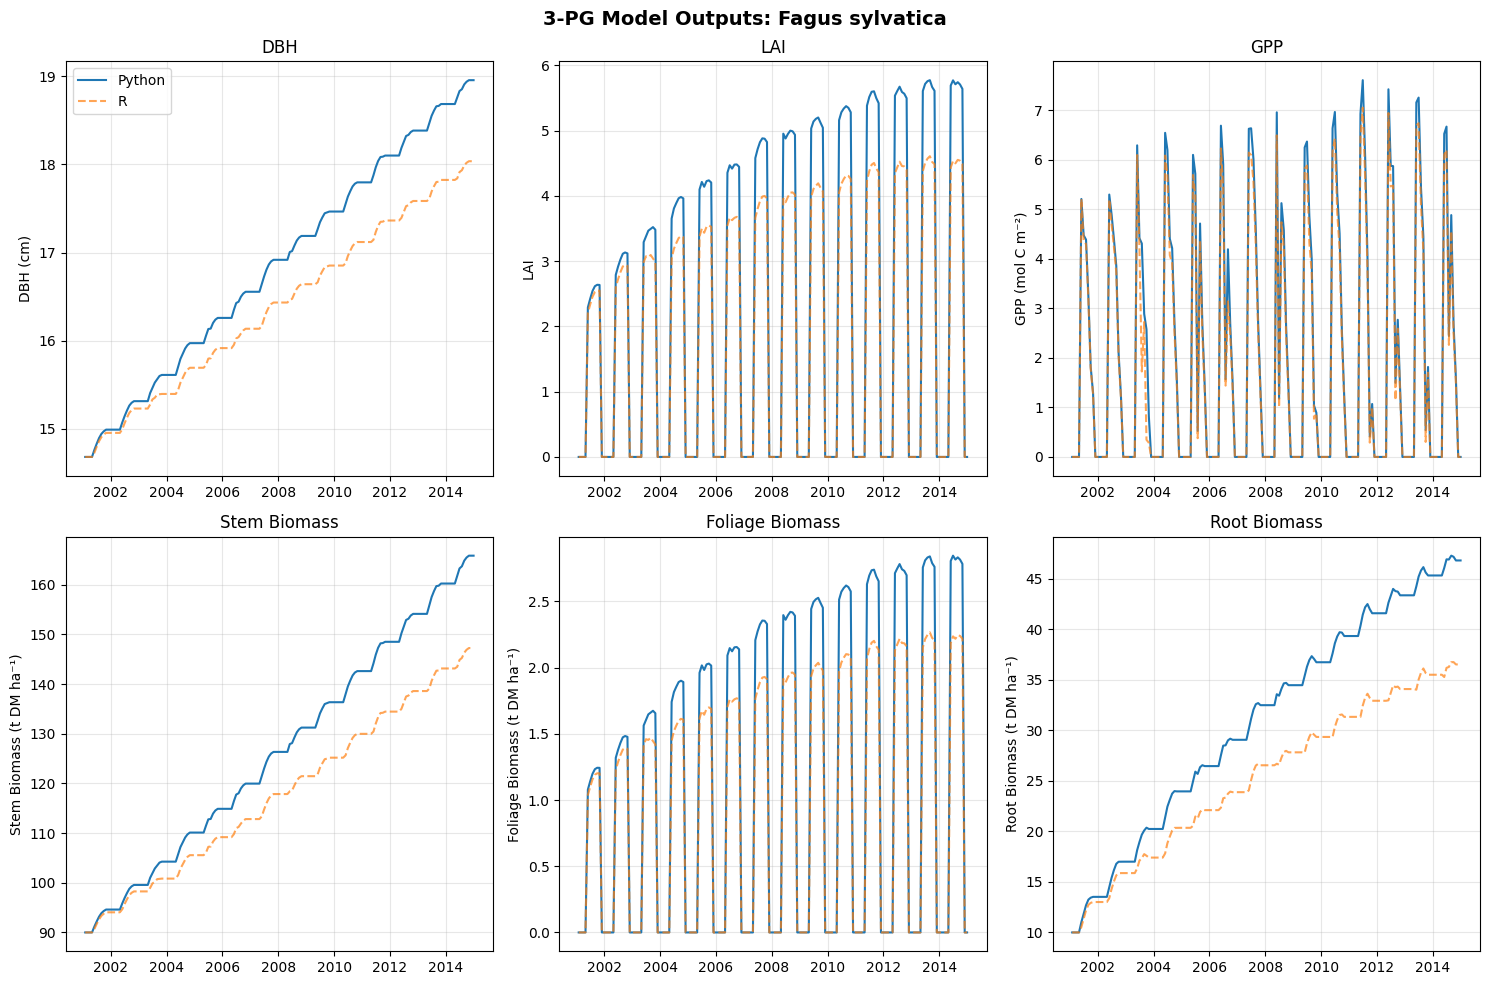

In [3]:
r_df = run_comparison_r(file_path)
r_df = pl.DataFrame(r_df)
species_names = r_df.select("species").unique().to_series().to_list()
fig, outputs = run_threepg_main(file_path, plot_output=True, r_comparison=True)

df = create_comparison_dataframe(r_df, outputs, np.datetime64("2001-01"), species_names)

# # df.head()

2026-06-02 14:34:59 - root - INFO - Pre-processed species data for 1 species


Final stem biomass (Mg/ha): [292.56064]
Final LAI: [14.440951]
Final WS: [292.56064]
piab: [∂WS/∂alphaCx, ∂WS/∂CoeffCond, ∂WS/∂Y] = [[1916.5015 ]
 [-620.11566]
 [ 274.14853]]
File path passed: ./data/solling_data.xlsx
Using custom file: ./data/solling_data.xlsx


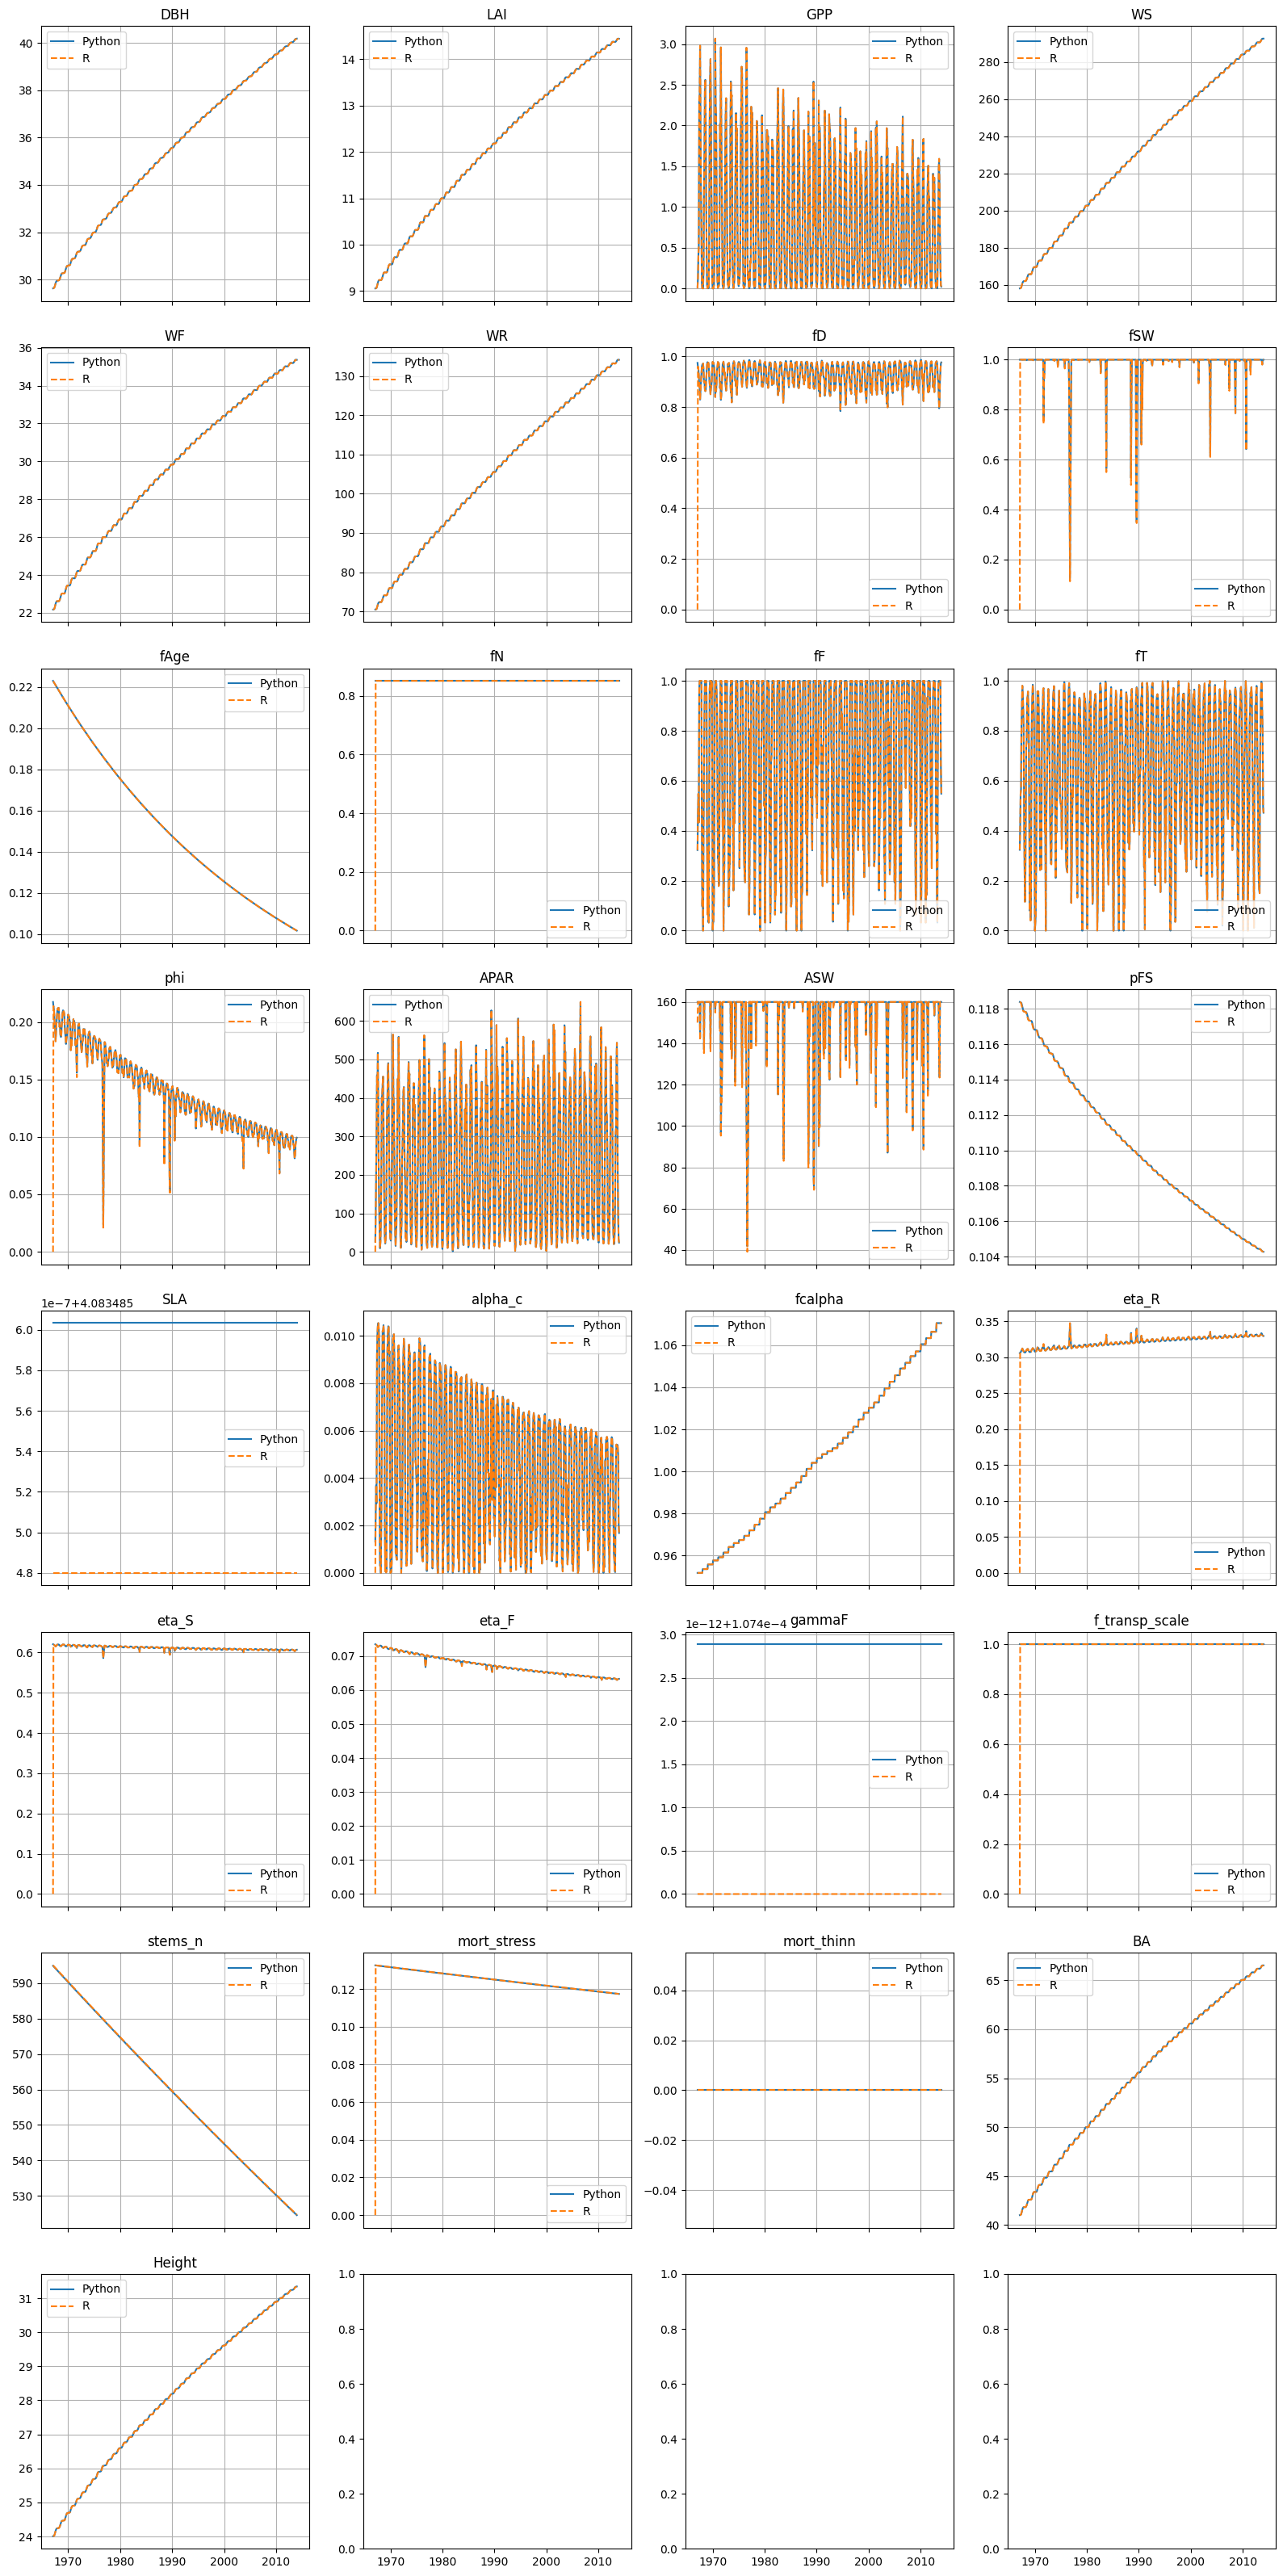

In [4]:
# file_path = "./data/data_sspecies_nothinning.xlsx"
file_path = "./data/solling_data.xlsx"
fig, outputs = run_threepg_main(file_path, plot_output=False, r_comparison=True)

# Ensure Dates column is datetime
df = pd.read_csv("./data/r_python.comparison.csv")
df["Dates"] = pd.to_datetime(df["Dates"])

py_metrics = [
    col for col in df.columns if not col.startswith("r_") and col != "Dates" and col != "species"
]

ncols = 4
n_metrics = len(py_metrics)
nrows = (n_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, py_col in zip(axes, py_metrics, strict=False):
    r_col = f"r_{py_col}"
    if r_col in df.columns:
        ax.plot(df["Dates"], df[py_col], label="Python", color="tab:blue")
        ax.plot(df["Dates"], df[r_col], label="R", color="tab:orange", linestyle="--")
        ax.set_title(py_col)
        ax.grid(True)
        ax.legend()

for i in range(len(py_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [5]:
import datetime as dt

import polars as pl

file_path = os.path.join("./data/", "S_weather_data.xlsx")
origin = dt.datetime(1970, 1, 1)
r_outputs = run_comparison_r(file_path)

r_outputs = (
    pl.DataFrame(r_outputs)
    .with_columns(
        pl.col("date")
        .map_elements(lambda x: origin + dt.timedelta(days=x), return_dtype=pl.Datetime)
        .alias("dates")
    )
    .with_columns(
        pl.col("dates").dt.year().alias("year"), pl.col("dates").dt.month().alias("month")
    )
)

r_outputs.head()

File path passed: ./data/S_weather_data.xlsx
Using custom file: ./data/S_weather_data.xlsx


date,species,group,variable,value,dates,year,month
f64,str,str,str,f64,datetime[μs],i32,i8
12448.0,"""Pinus sylvestris""","""climate""","""tmp_min""",-2.527419,2004-01-31 00:00:00,2004,1
12477.0,"""Pinus sylvestris""","""climate""","""tmp_min""",-3.584483,2004-02-29 00:00:00,2004,2
12508.0,"""Pinus sylvestris""","""climate""","""tmp_min""",-1.46129,2004-03-31 00:00:00,2004,3
12538.0,"""Pinus sylvestris""","""climate""","""tmp_min""",2.768333,2004-04-30 00:00:00,2004,4
12569.0,"""Pinus sylvestris""","""climate""","""tmp_min""",5.117742,2004-05-31 00:00:00,2004,5
